<div style="
    background: #0f3460;
    padding: 14px 48px;
    border-left: 5px solid #e94560;
    font-family: 'Segoe UI', sans-serif;
    width: 100vw;
    box-sizing: border-box;
    position: relative;
    left: 50%;
    transform: translateX(-50%);
    overflow: hidden;
">
    <p style="color: rgba(255,255,255,0.5); font-size: 0.75em; margin: 0 0 4px 0;
       letter-spacing: 2px; text-transform: uppercase;">
        Nhập môn học máy &nbsp;|&nbsp; Báo cáo Đồ án 3 &nbsp;|&nbsp; CQ2023/24
    </p>
    <div style="display: flex; align-items: baseline; gap: 20px; flex-wrap: wrap;">
        <div>
            <h1 style="color: #ffffff; font-size: 1.4em; margin: 0 0 2px 0; font-weight: 700;">
                Notebook: MNIST Rotation Invariance
            </h1>
            <p style="color: #89b4fa; font-size: 0.88em; margin: 0;">
                2D Digit Recognition · Baseline CNN · Data Augmentation · Frame Averaging
            </p>
        </div>
        <span style="color: rgba(255,255,255,0.5); font-size: 0.8em; margin-left: auto; white-space: nowrap;">
            10 classes &nbsp;·&nbsp; 3 models &nbsp;·&nbsp; MNIST dataset
        </span>
    </div>
</div>


## Mục lục

- [1. Chuẩn bị dữ liệu](#1.-chuẩn-bị-dữ-liệu)
  - [1.1 Hiển thị một số dữ liệu minh họa](#1.1-hiển-thị-một-số-dữ-liệu-minh-họa)
- [2. Định nghĩa mô hình CNN](#2.-định-nghĩa-mô-hình-cnn)
- [3. Hàm huấn luyện](#3.-hàm-huấn-luyện)
  - [3.1 Huấn luyện mô hình Baseline](#3.1-huấn-luyện-mô-hình-baseline)
  - [3.2 Huấn luyện mô hình Data Augmentation](#3.2-huấn-luyện-mô-hình-data-augmentation)
  - [3.3 Huấn luyện mô hình Frame Averaging](#3.3-huấn-luyện-mô-hình-frame-averaging)
- [4. Lưu trọng số mô hình](#4.-lưu-trọng-số-mô-hình)
- [5. Kết luận](#5.-kết-luận)


Notebook này trình bày quy trình huấn luyện ba mô hình CNN trên tập dữ liệu MNIST, mỗi mô hình tiếp cận bài toán bất biến phép xoay theo một cách khác nhau:

1. **Baseline CNN**: Huấn luyện trên ảnh MNIST gốc, không xử lý phép xoay.
2. **Data Augmentation CNN**: Huấn luyện với ảnh xoay ngẫu nhiên, học tính bất biến xấp xỉ từ dữ liệu.
3. **Frame Averaging CNN**: giống Baseline nhưng tính bất biến được đưa vào bước suy luận qua cơ chế lấy trung bình khung.

Trọng số sau khi huấn luyện được lưu vào `storage/weights/` và được Backend FastAPI sử dụng cho tính năng demo tương tác.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Cấu hình thiết bị (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")


Đang sử dụng thiết bị: cpu


## **1. Chuẩn bị dữ liệu**

Tập dữ liệu MNIST gồm 70,000 ảnh chữ số viết tay grayscale kích thước $28 \times 28$ pixel, chia thành:
- **60,000 ảnh** để huấn luyện
- **10,000 ảnh** để kiểm tra

Mỗi ảnh thuộc một trong 10 lớp chữ số 0–9. Tập dữ liệu này được tải tự động qua `torchvision.datasets.MNIST`.

Trong notebook này, ta định nghĩa ba DataLoader tương ứng với ba phương pháp huấn luyện:

| DataLoader | Transform | Mục đích |
|---|---|---|
| `trainloader_baseline` | Không xoay | Baseline CNN phụ thuộc hướng gốc |
| `trainloader_augmented` | `RandomRotation(180)` | Augmented CNN học bất biến xoay xấp xỉ |
| `trainloader_frame` | `RandomRotation(180)` | Frame Averaging CNN dùng cùng augmented data nhưng wrap bằng frame |
| `testloader` | Không xoay | Đánh giá chung cho cả ba mô hình |


In [2]:
# Phép biến đổi cơ bản cho Baseline
transform_baseline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Phép biến đổi Tăng cường dữ liệu (Data Augmentation)
transform_augmented = transforms.Compose([
    transforms.RandomRotation(180), # Xoay ngẫu nhiên -180 đến 180 độ
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Tải Dataset
trainset_baseline = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_baseline)
trainloader_baseline = torch.utils.data.DataLoader(trainset_baseline, batch_size=64, shuffle=True)

trainset_augmented = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_augmented)
trainloader_augmented = torch.utils.data.DataLoader(trainset_augmented, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_baseline)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)


### **1.1 Hiển thị một số dữ liệu minh họa**

Trực quan một batch ảnh từ hai DataLoader ảnh gốc và ảnh đã xoay ngẫu nhiên để minh họa sự khác biệt về phân phối dữ liệu đầu vào giữa hai chiến lược huấn luyện.


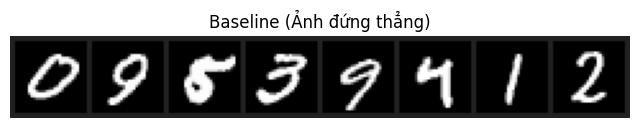

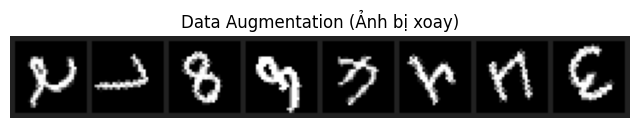

In [3]:
def imshow(img, title):
    img = img * 0.3081 + 0.1307     # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Hiển thị ảnh Baseline
dataiter = iter(trainloader_baseline)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]), "Baseline (Ảnh đứng thẳng)")

# Hiển thị ảnh Data Augmentation
dataiter_aug = iter(trainloader_augmented)
images_aug, labels_aug = next(dataiter_aug)
imshow(torchvision.utils.make_grid(images_aug[:8]), "Data Augmentation (Ảnh bị xoay)")


## **2. Định nghĩa mô hình CNN**

Cả ba mô hình dùng cùng backbone CNN để việc so sánh tập trung hoàn toàn vào cơ chế xử lý đối xứng, không phải vào sức mạnh kiến trúc.

Kiến trúc:

$$\mathrm{Conv}(1{\to}16,\ k=5) \to \mathrm{MaxPool}(2) \to \mathrm{Conv}(16{\to}32,\ k=5) \to \mathrm{MaxPool}(2) \to \mathrm{FC}(1568{\to}128) \to \mathrm{FC}(128{\to}10)$$

Ảnh đầu vào được chuẩn hóa theo thống kê MNIST: $\mu = 0.1307$, $\sigma = 0.3081$.


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2) # 28x28 -> 28x28
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2) # 28x28 -> 14x14
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2) # 14x14 -> 14x14
        self.fc1 = nn.Linear(32 * 7 * 7, 128) # Sau maxpool lần 2 là 7x7
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.maxpool(self.relu(self.conv1(x)))
        x = self.maxpool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7) # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("Kiến trúc mô hình:")
print(SimpleCNN())


Kiến trúc mô hình:
SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## **3. Hàm huấn luyện**

Hàm `train_model(model, dataloader, epochs)` thực hiện vòng lặp huấn luyện tiêu chuẩn:
- **Loss**: CrossEntropyLoss
- **Optimizer**: Adam (lr = 0.001)
- **Epochs**: 3

Cả ba mô hình đều được huấn luyện trên cùng một thiết bị CPU hoặc GPU nếu có với cùng số epoch để so sánh công bằng.


In [5]:
def train_model(model, trainloader, epochs=3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            if i % 300 == 299:    # print every 300 mini-batches
                print(f'[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / 300:.3f}')
                running_loss = 0.0
    print('Huấn luyện hoàn tất!')
    return model


### **3.1 Huấn luyện mô hình Baseline**

Mô hình Baseline CNN được huấn luyện trên ảnh MNIST gốc. Đây là cấu hình tham chiếu - mô hình học tốt trên ảnh thẳng đứng nhưng không có tính bất biến với phép xoay.

Khi ảnh đầu vào bị xoay ra khỏi phân phối gốc đặc biệt ở các góc lớn như $90°$ hay $180°$, dự đoán của Baseline dễ thay đổi mạnh. Đây là biểu hiện điển hình khi mô hình thiếu *inductive bias* hình học.


In [6]:
print("Bắt đầu huấn luyện BASELINE MODEL...")
model_baseline = SimpleCNN()
model_baseline = train_model(model_baseline, trainloader_baseline, epochs=3)


Bắt đầu huấn luyện BASELINE MODEL...
[Epoch 1, Batch   300] loss: 0.287
[Epoch 1, Batch   600] loss: 0.087
[Epoch 1, Batch   900] loss: 0.066
[Epoch 2, Batch   300] loss: 0.049
[Epoch 2, Batch   600] loss: 0.046
[Epoch 2, Batch   900] loss: 0.045
[Epoch 3, Batch   300] loss: 0.028
[Epoch 3, Batch   600] loss: 0.030
[Epoch 3, Batch   900] loss: 0.033
Huấn luyện hoàn tất!


**Kết quả quan sát:** Loss giảm từ ~0.31 ở batch đầu epoch 1 xuống ~0.03 ở cuối epoch 3.


### **3.2 Huấn luyện mô hình Data Augmentation**

Mô hình Augmented CNN giữ nguyên kiến trúc backbone, nhưng dữ liệu huấn luyện được biến đổi bằng phép xoay ngẫu nhiên:

$$\texttt{RandomRotation}(180) \to \texttt{ToTensor()} \to \texttt{Normalize}(0.1307,\ 0.3081)$$

Bằng cách tiếp xúc với nhiều góc xoay trong quá trình huấn luyện, mô hình học được tính bất biến xoay ở mức xấp xỉ. Tuy nhiên, với một số cặp chữ số có hình dạng gần nhau sau khi xoay (ví dụ: 6 và 9 ở góc $180°$), bản thân nhãn trở nên mơ hồ nên đây là giới hạn cố hữu của data augmentation.


In [7]:
print("\nBắt đầu huấn luyện AUGMENTED MODEL...")
model_augmented = SimpleCNN()
model_augmented = train_model(model_augmented, trainloader_augmented, epochs=3)



Bắt đầu huấn luyện AUGMENTED MODEL...
[Epoch 1, Batch   300] loss: 0.982
[Epoch 1, Batch   600] loss: 0.472
[Epoch 1, Batch   900] loss: 0.342
[Epoch 2, Batch   300] loss: 0.281
[Epoch 2, Batch   600] loss: 0.231
[Epoch 2, Batch   900] loss: 0.205
[Epoch 3, Batch   300] loss: 0.195
[Epoch 3, Batch   600] loss: 0.181
[Epoch 3, Batch   900] loss: 0.175
Huấn luyện hoàn tất!


**Kết quả quan sát:** Loss cao hơn Baseline ở đầu (~0.96) vì bài toán có nhiều tư thế hơn, nhưng giảm dần xuống ~0.16 sau epoch 3.


### **3.3 Huấn luyện mô hình Frame Averaging**

Mô hình Frame Averaging CNN sử dụng cùng backbone `SimpleCNN`, nhưng được bọc bên ngoài bằng lớp `FrameAveragingCNN`.

**Cơ chế hoạt động trong quá trình huấn luyện:**

1. **PCA**: Với mỗi ảnh đầu vào, tính ma trận hiệp phương sai của các điểm ảnh sáng (pixel > 0.2) rồi lấy vector riêng chính. Đây là *hướng chính* của nét chữ.

2. **Frame set**: Tạo 4 bản sao xoay lệch nhau $90°$ so với hướng PCA:
$$\mathcal{F}(I) = \{\mathrm{Rot}(I,\ -\theta_{\text{PCA}} + k \cdot 90°) \mid k = 0, 1, 2, 3\}$$

3. **Trung bình logits**: Đưa cả 4 frame qua backbone, lấy trung bình cộng logits:
$$\hat{y} = \frac{1}{4}\sum_{k=0}^{3} f_\theta\!\left(\mathrm{Rot}(I,\ -\theta_{\text{PCA}} + k \cdot 90°)\right)$$

Khác với Data Augmentation, Frame Averaging đưa cấu trúc đối xứng trực tiếp vào bước suy luận nên mô hình ổn định hơn dưới phép xoay mà không cần nhãn mơ hồ.


In [8]:
import math
import torchvision.transforms.functional as TF

def get_pca_angles_batch(images):
    B = images.shape[0]
    angles = torch.zeros(B, device=images.device)
    for i in range(B):
        img = images[i, 0]
        threshold = 0.2
        y_indices, x_indices = torch.where(img > threshold)
        if len(x_indices) < 2:
            angles[i] = 0.0
            continue
            
        x_coords = x_indices.float()
        y_coords = y_indices.float()
        
        x_mean = torch.mean(x_coords)
        y_mean = torch.mean(y_coords)
        x_centered = x_coords - x_mean
        y_centered = y_coords - y_mean
        
        coords = torch.stack([x_centered, y_centered], dim=0)
        cov_matrix = torch.matmul(coords, coords.T) / (len(x_coords) - 1)
        
        eigenvalues, eigenvectors = torch.linalg.eigh(cov_matrix)
        principal_vector = eigenvectors[:, 1]
        
        angle_rad = torch.atan2(principal_vector[1], principal_vector[0])
        angle_deg = math.degrees(angle_rad.item())
        angles[i] = angle_deg
    return angles

class FrameAveragingCNN(nn.Module):
    def __init__(self, backbone):
        super(FrameAveragingCNN, self).__init__()
        self.backbone = backbone
        
    def forward(self, x):
        B = x.shape[0]
        angles = get_pca_angles_batch(x)
        
        rotated_images = []
        for i in range(B):
            base_angle = -angles[i].item()
            for offset in [0, 90, 180, 270]:
                rot_img = TF.rotate(x[i], base_angle + offset)
                rotated_images.append(rot_img)
        
        rotated_batch = torch.stack(rotated_images, dim=0)
        
        logits = self.backbone(rotated_batch)
        
        logits = logits.view(B, 4, 10)
        avg_logits = torch.mean(logits, dim=1)
        
        return avg_logits


In [9]:
print("\nBắt đầu huấn luyện FRAME AVERAGING MODEL...")
backbone_fa = SimpleCNN()
model_frame = FrameAveragingCNN(backbone_fa)
model_frame = train_model(model_frame, trainloader_baseline, epochs=3)



Bắt đầu huấn luyện FRAME AVERAGING MODEL...
[Epoch 1, Batch   300] loss: 0.824
[Epoch 1, Batch   600] loss: 0.288
[Epoch 1, Batch   900] loss: 0.186
[Epoch 2, Batch   300] loss: 0.141
[Epoch 2, Batch   600] loss: 0.113
[Epoch 2, Batch   900] loss: 0.112
[Epoch 3, Batch   300] loss: 0.084
[Epoch 3, Batch   600] loss: 0.077
[Epoch 3, Batch   900] loss: 0.076
Huấn luyện hoàn tất!



**Kết quả quan sát:** Loss giảm từ ~0.77 ở batch đầu epoch 1 xuống ~0.08 ở cuối epoch 3.


## **4. Lưu trọng số mô hình**

Sau khi huấn luyện, backbone của từng mô hình được lưu dưới dạng file `.pth` vào thư mục `storage/weights/`:

| File | Mô hình |
|---|---|
| `model_baseline.pth` | Trọng số backbone Baseline CNN |
| `model_augmented.pth` | Trọng số backbone Augmented CNN |
| `model_frame.pth` | Trọng số backbone Frame Averaging CNN |

> **Lưu ý:** Chỉ lưu trọng số của **backbone** (`SimpleCNN`), không lưu wrapper `FrameAveragingCNN`. Khi inference, Backend sẽ load backbone rồi wrap lại bằng `FrameAveragingCNN` từ `backend/core/frame_averaging.py`.


In [10]:
import os
from pathlib import Path
# Auto-detect if cwd is the project root or the notebook dir
cwd = Path(os.getcwd())
backend_dir = None
for p in [cwd, cwd / '..', cwd / '../..', cwd / '../../..']:
    resolved = p.resolve()
    if (resolved / 'backend' / 'main.py').exists():
        backend_dir = resolved / 'backend'
        break
if backend_dir is not None:
    models_dir = str((backend_dir / '../storage/weights').resolve())
else:
    models_dir = '../storage/weights'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
torch.save(model_baseline.state_dict(), os.path.join(models_dir, 'model_baseline.pth'))
torch.save(model_augmented.state_dict(), os.path.join(models_dir, 'model_augmented.pth'))
torch.save(model_frame.backbone.state_dict(), os.path.join(models_dir, 'model_frame.pth'))
print("Đã lưu model_baseline.pth, model_augmented.pth, và model_frame.pth thành công vào backend/models!")


Đã lưu model_baseline.pth, model_augmented.pth, và model_frame.pth thành công vào backend/models!


## **5. Kết luận**

Ba mô hình được huấn luyện trong cùng điều kiện: cùng backbone, cùng số epoch, cùng optimizer, chỉ khác ở cách xử lý phép xoay. Bảng dưới tổng hợp loss cuối epoch 3 từ kết quả thực tế:

| Mô hình | Loss đầu epoch 1 | Loss cuối epoch 3 | Cơ chế bất biến |
|---|---|---|---|
| Baseline CNN | ~0.31 | ~0.03 | Không có |
| Augmented CNN | ~0.96 | ~0.16 | Học từ dữ liệu xoay |
| Frame Averaging CNN | ~0.77 | ~0.08 | Trung bình trên frame |

Từ kết quả trên có thể rút ra một số điểm:

- Baseline có loss cuối thấp nhất nhưng đây không phải dấu hiệu tốt. Nó đang giải quyết bài toán đơn giản nhất khi toàn bộ ảnh huấn luyện đều thẳng đứng. Khi triển khai với ảnh tùy góc xoay ở demo web, mô hình này sẽ có hiệu suất kém nhất trong ba.

- Frame Averaging có loss đầu cao (~0.77) do mỗi ảnh bị xử lý thành 4 phiên bản xoay trước khi tính trung bình logits, nhưng lại hội tụ, đạt ~0.08 sau epoch 3. Điều này gợi ý rằng việc đưa cấu trúc đối xứng vào bước suy luận giúp gradient có hướng ổn định hơn trong quá trình tối ưu.

- Augmented có loss cuối cao nhất (~0.16) do hai nguyên nhân: một phần vì bài toán có nhãn mơ hồ ở một số cặp chữ số sau khi xoay, phần còn lại vì tính bất biến chỉ được kỳ vọng học được qua dữ liệu chứ không được đảm bảo bởi kiến trúc.

Thí nghiệm này minh họa một điểm cốt lõi trong học máy hình học: khi bài toán có cấu trúc đối xứng rõ ràng, mã hóa đối xứng đó vào kiến trúc mang lại lợi ích về cả tốc độ hội tụ lẫn tính ổn định, thay vì để mô hình tự suy luận ra từ dữ liệu.
